# Mining Process – % Silica Concentrate Prediction

This project aims to develop a **machine learning regression model** to predict the **% Silica Concentrate** in a mining flotation process using operational plant data.  
Accurate prediction of silica concentration is essential to improve process efficiency, reduce laboratory dependency, and support real-time decision-making in the field. The code is divided into five main parts, which are:
1. Imports & Configurations;
2. Dataset Treatment;  
3. Applying Ensemble Model; 
4. Result Analysis;
5. Predicting the Future.


**Responsible:** Paulo Casmal

**Email:** <paulo.casmal@gmail.com>

**Start Date:** 01-31-2026 | **Submission Date:** 


---


## 01 - Imports & Configurations

In [441]:
# import necessary libraries
import locale
import pandas as pd
import numpy as np  
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# import machine learning models to compare performance
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from statsmodels.tsa.arima.model import ARIMA
from sklearn.neural_network import MLPRegressor
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [442]:
# Configuration of matplotlib parameters for consistent styling
mpl.rcParams['figure.figsize'] = (10, 5)  # Default figure size
mpl.rc('lines', lw=2)  # Sets the line width
mpl.rcParams['grid.linewidth'] = 0.5  # Grid line width
mpl.rcParams['grid.linestyle'] = 'dashed'  # Grid line style
mpl.rc(('xtick', 'ytick'), labelsize=15)  # Axis tick label size
mpl.rc('font', family='Arial', size=15)  # Font family and font size
mpl.rcParams['axes.linewidth'] = 0.5 # - Largura das bordas dos gráficos

In [443]:
try:
    locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8') 
except:
    locale.setlocale(locale.LC_ALL, 'portuguese_brazil')

# 2. Informa ao Matplotlib para usar o separador do locale
mpl.rcParams['axes.formatter.use_locale'] = True

In [444]:
# Load the dataset
path = r'C:\Users\paulo\Downloads\archive (2)\MiningProcess_Flotation_Plant_Database.csv'

df = pd.read_csv(path, decimal=',')

df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


## 02 - Dataset treatment

In [445]:
# Convert 'date' column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

In [446]:
df.columns

Index(['% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', '% Silica Concentrate'],
      dtype='object')

Drop the '% Iron Concentrate' column due to high correlation with target variable. Additionaly, this variable can be measured only at laboratory, which not helps to predict the '% Silica Concentrate' in field.

In [447]:
df = df[['% Iron Concentrate', '% Silica Concentrate']]

In [448]:
df = df.resample("1H").mean()

In [449]:
df = df.drop_duplicates(keep='first')

EDA was performed in a separate script. It does not indicate any major problem with data.

In [450]:
df = df.rename(columns={'% Iron Concentrate': 'Iron_Concentrate', '% Silica Concentrate': 'Silica_Concentrate'})
df = df.drop(columns=['Iron_Concentrate'])

### 2.3 - Lag Features

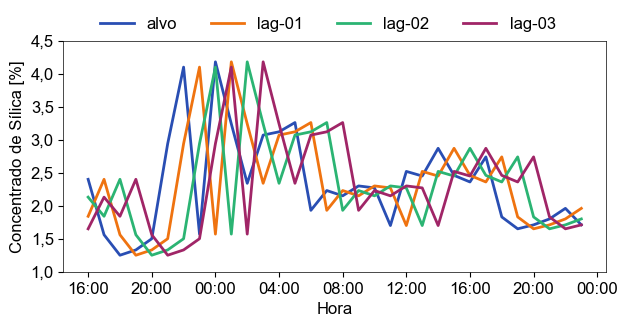

In [451]:
mpl.rc(('xtick', 'ytick'), labelsize=12)  # Axis tick label size
mpl.rc('font', family='Arial', size=12)  # Font family and font size

# Just for visualization purposes
view = df.sort_index().copy()

view = view[view.index > '2017-09-08 00:00:00']

target_col = "Silica_Concentrate"

for lag in range(1, 15):
    view[f"lag-{lag}"] = view[target_col].shift(lag)

view = view.dropna()

fig, ax = plt.subplots(figsize=(7, 3))

ax.plot(view.index, view['Silica_Concentrate'], label='alvo', c='#294EB3')
ax.plot(view.index, view['lag-1'], c='#EF7310', label='lag-01')
ax.plot(view.index, view['lag-2'], c='#2BB473', label='lag-02')
ax.plot(view.index, view['lag-3'], c="#A02567", label='lag-03')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax.legend(ncol=4, loc='upper left', bbox_to_anchor=(0.04, 1.17), frameon=False)
ax.set_ylabel('Concentrado de Sílica [%]')
ax.set_xlabel('Hora')

ax.set_yticks(np.arange(1, 5, 0.5))
fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\lag-features.svg', dpi=140, format='svg', transparent=True)

plt.show()


In [452]:
df = df.sort_index()

target_col = "Silica_Concentrate"

for col in df.columns:
    for lag in range(1, 15):
        df[f"lag-{lag}"] = df[col].shift(lag)

df = df.dropna()

In [453]:
# df = df.drop(columns=['Iron_Concentrate'])

### 2.4 - Cross-Validation

In [454]:
# Using specific time series train test split method
tss = TimeSeriesSplit(n_splits=5, test_size=24*14, gap=24) # 14 days data for testing

df = df.sort_index()

df = df.dropna()

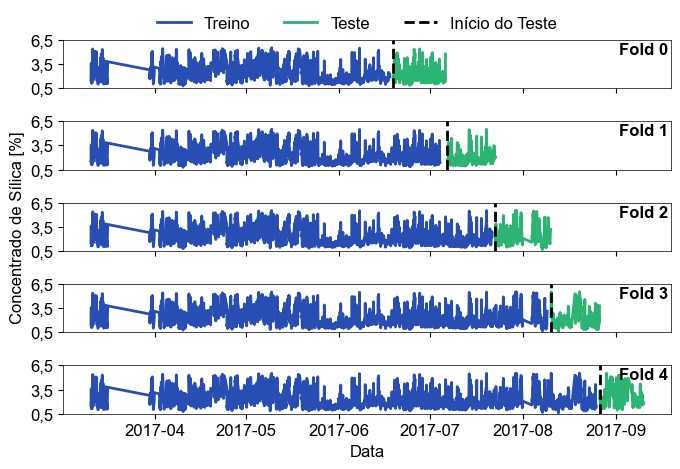

In [455]:
# Just for visualization purposes
fig, axs = plt.subplots(5, 1, figsize=(7, 5), sharex=True)

# Plot each fold
for fold, (train_index, test_index) in enumerate(tss.split(df)):
    train = df.iloc[train_index]
    test = df.iloc[test_index]

    axs[fold].plot(train.index, train['Silica_Concentrate'], label='Treino', c='#294EB3')
    axs[fold].plot(test.index, test['Silica_Concentrate'], label='Teste', c="#2BB473")
    axs[fold].axvline(x=test.index[0], color='k', linestyle='--', label='Início do Teste')

    axs[fold].text(0.915, 0.7, f'Fold {fold}', fontsize=12, transform=axs[fold].transAxes, fontweight='bold')

    axs[fold].set_yticks(np.arange(0.5, 7, 3))
    axs[fold].set_ylim(0.5, 6.5)


axs[2].set_ylabel('Concentrado de Sílica [%]')

axs[0].legend(ncol=3, loc='upper left', bbox_to_anchor=(0.13, 1.8), frameon=False)

plt.xlabel('Data')
plt.tight_layout()

fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\time-series-split.svg', dpi=140, format='svg', transparent=True)

plt.show()

## 03 - Comparing Models

In [456]:
df.columns

Index(['Silica_Concentrate', 'lag-1', 'lag-2', 'lag-3', 'lag-4', 'lag-5',
       'lag-6', 'lag-7', 'lag-8', 'lag-9', 'lag-10', 'lag-11', 'lag-12',
       'lag-13', 'lag-14'],
      dtype='object')

In [457]:
target = 'Silica_Concentrate'
lags_to_test = range(1, 14, 3)

### 3.1 - XGBoost

In [458]:
# Configurações iniciais
all_results = []

# Loop principal para testar diferentes quantidades de lags
for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO COM {n_lags} LAGS ")
    print(f"{'='*30}")

    # Métricas para este conjunto de lags (média dos folds)
    fold_metrics = []
    temp_best_model = None
    temp_best_rmse = np.inf

    # 2. Cross-Validation (TimeSeriesSplit)
    tss = TimeSeriesSplit(n_splits=5) # Ajuste conforme necessário
    
    for fold, (train_index, test_index) in enumerate(tss.split(df)):
        train = df.iloc[train_index]
        test = df.iloc[test_index]

        X_train_full = train.drop(columns=[target])
        y_train_full = train[target]
        X_test = test.drop(columns=[target])
        y_test = test[target]

        # Split validação para Early Stopping
        split_idx = int(len(X_train_full) * 0.9)
        X_train, X_val = X_train_full.iloc[:split_idx], X_train_full.iloc[split_idx:]
        y_train, y_val = y_train_full.iloc[:split_idx], y_train_full.iloc[split_idx:]

        model_xgb = xgb.XGBRegressor(
            n_estimators=1000,
            learning_rate=0.01,
            max_depth=3,
            objective='reg:squarederror',
            early_stopping_rounds=50,
            random_state=42
        )

        model_xgb.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False # Silenciar para não poluir o terminal
        )

        y_pred_xgb = model_xgb.predict(X_test)

        X_test_xgb = X_test
        y_test_xgb = y_test

        rmse = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
        r2 = r2_score(y_test_xgb, y_pred_xgb)
        mae = mean_absolute_error(y_test_xgb, y_pred_xgb)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

        if rmse < temp_best_rmse:
            temp_best_rmse = rmse
            temp_best_model = model_xgb

    # 3. Calcular média das métricas deste experimento
    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])
    avg_mae = np.mean([m['mae'] for m in fold_metrics])

    print(f"Média Final ({n_lags} lags) -> RMSE: {avg_rmse:.4f} | R²: {avg_r2:.4f}")

    # Guardar dados do experimento
    all_results.append({
        'n_lags': n_lags,
        'rmse_avg': avg_rmse,
        'r2_avg': avg_r2,
        'mae_avg': avg_mae,
        'best_model_obj': temp_best_model,
        'params': model_xgb.get_params()
    })

# 4. Rankear e pegar os 3 melhores (pelo RMSE médio)
top_3_results = sorted(all_results, key=lambda x: x['rmse_avg'])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES MODELOS")
print("#"*40)

for i, res in enumerate(top_3_results):
    print(f"{i+1}º Lugar: {res['n_lags']} Lags | RMSE Médio: {res['rmse_avg']:.4f}")


 TESTANDO COM 1 LAGS 
Média Final (1 lags) -> RMSE: 0.7583 | R²: 0.4911

 TESTANDO COM 4 LAGS 
Média Final (4 lags) -> RMSE: 0.7583 | R²: 0.4911

 TESTANDO COM 7 LAGS 
Média Final (7 lags) -> RMSE: 0.7583 | R²: 0.4911

 TESTANDO COM 10 LAGS 
Média Final (10 lags) -> RMSE: 0.7583 | R²: 0.4911

 TESTANDO COM 13 LAGS 
Média Final (13 lags) -> RMSE: 0.7583 | R²: 0.4911


########################################
      TOP 3 MELHORES MODELOS
########################################
1º Lugar: 1 Lags | RMSE Médio: 0.7583
2º Lugar: 4 Lags | RMSE Médio: 0.7583
3º Lugar: 7 Lags | RMSE Médio: 0.7583


In [459]:
rmse_list_xgb = []
r2_list_xgb = []
mae_list_xgb = []
lags_xgb = []

for i in range(len(all_results)):
    lags_xgb.append(all_results[i]['n_lags'])
    rmse_list_xgb.append(all_results[i]['rmse_avg'])
    r2_list_xgb.append(all_results[i]['r2_avg'])
    mae_list_xgb.append(all_results[i]['mae_avg'])

### 3.2 - Random Forest

In [460]:
# Configurações iniciais
all_results_rf = [] # Lista específica para Random Forest

for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO RANDOM FOREST: {n_lags} LAGS ")
    print(f"{'='*30}")
    
    fold_metrics = []
    temp_best_model = None
    temp_best_rmse = np.inf

    # 2. Cross-Validation
    tss = TimeSeriesSplit(n_splits=5)
    
    for fold, (train_index, test_index) in enumerate(tss.split(df)):
        train = df.iloc[train_index]
        test = df.iloc[test_index]

        X_train = train.drop(columns=[target])
        y_train = train[target]
        X_test = test.drop(columns=[target])
        y_test = test[target]

        # Instanciando Random Forest
        # Usei n_estimators=200 para equilíbrio entre performance e tempo, 
        # mas você pode aumentar para 500 ou 1000 se o PC aguentar.
        model_rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=10, # RF geralmente precisa de mais profundidade que XGBoost
            random_state=42,
            n_jobs=-1 # Usa todos os núcleos do seu processador
        )

        model_rf.fit(X_train, y_train)

        y_pred_rf = model_rf.predict(X_test)

        X_test_rf = X_test
        y_test_rf = y_test
        
        rmse = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
        r2 = r2_score(y_test_rf, y_pred_rf)
        mae = mean_absolute_error(y_test_rf, y_pred_rf)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

        if rmse < temp_best_rmse:
            temp_best_rmse = rmse
            temp_best_model = model_rf

    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])
    avg_mae = np.mean([m['mae'] for m in fold_metrics])

    print(f"Média Final RF ({n_lags} lags) -> RMSE: {avg_rmse:.4f} | R²: {avg_r2:.4f}")

    # Guardar com sufixo rfs para futura comparação
    all_results_rf.append({
        'n_lags_rfs': n_lags,
        'rmse_avg_rfs': avg_rmse,
        'r2_avg_rfs': avg_r2,
        'mae_avg_rfs': avg_mae,
        'model_obj_rfs': temp_best_model,
        'params_rfs': model_rf.get_params()
    })

# 4. Rankear Top 3
top_3_rf = sorted(all_results_rf, key=lambda x: x['rmse_avg_rfs'])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES - RANDOM FOREST")
print("#"*40)
for i, res in enumerate(top_3_rf):
    print(f"{i+1}º Lugar: {res['n_lags_rfs']} Lags | RMSE Médio: {res['rmse_avg_rfs']:.4f}")


 TESTANDO RANDOM FOREST: 1 LAGS 
Média Final RF (1 lags) -> RMSE: 0.7625 | R²: 0.4844

 TESTANDO RANDOM FOREST: 4 LAGS 
Média Final RF (4 lags) -> RMSE: 0.7625 | R²: 0.4844

 TESTANDO RANDOM FOREST: 7 LAGS 
Média Final RF (7 lags) -> RMSE: 0.7625 | R²: 0.4844

 TESTANDO RANDOM FOREST: 10 LAGS 
Média Final RF (10 lags) -> RMSE: 0.7625 | R²: 0.4844

 TESTANDO RANDOM FOREST: 13 LAGS 
Média Final RF (13 lags) -> RMSE: 0.7625 | R²: 0.4844


########################################
      TOP 3 MELHORES - RANDOM FOREST
########################################
1º Lugar: 7 Lags | RMSE Médio: 0.7625
2º Lugar: 10 Lags | RMSE Médio: 0.7625
3º Lugar: 13 Lags | RMSE Médio: 0.7625


In [461]:
rmse_list_rf = []
r2_list_rf = []
mae_list_rf = []
lags_rf = []

for i in range(len(all_results_rf)):
    lags_rf.append(all_results_rf[i]['n_lags_rfs'])
    rmse_list_rf.append(all_results_rf[i]['rmse_avg_rfs'])
    r2_list_rf.append(all_results_rf[i]['r2_avg_rfs'])
    mae_list_rf.append(all_results_rf[i]['mae_avg_rfs'])

### 3.3 - Multi Layer Perceptron

In [462]:
# Configurações iniciais
all_results_mlp = [] # Lista específica para MLP

for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO MLP (REDE NEURAL): {n_lags} LAGS ")
    print(f"{'='*30}")
    
    fold_metrics = []
    temp_best_model = None
    temp_best_rmse = np.inf

    # 2. Cross-Validation
    tss = TimeSeriesSplit(n_splits=5)
    
    for fold, (train_index, test_index) in enumerate(tss.split(df)):
        train = df.iloc[train_index]
        test = df.iloc[test_index]

        X_train_raw = train.drop(columns=[target])
        y_train = train[target]
        X_test_raw = test.drop(columns=[target])
        y_test = test[target]

        # --- IMPORTANTE: Escalonamento de Dados para MLP ---
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # Instanciando MLP
        # Arquitetura (64, 32) costuma ser um bom ponto de partida para regressão
        model_mlp = MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            solver='adam',
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=42
        )

        model_mlp.fit(X_train, y_train)

        y_pred_mlps = model_mlp.predict(X_test)

        X_test_mlps = X_test 
        y_test_mlps = y_test

        rmse = np.sqrt(mean_squared_error(y_test_mlps, y_pred_mlps))
        r2 = r2_score(y_test_mlps, y_pred_mlps)
        mae = mean_absolute_error(y_test_mlps, y_pred_mlps)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

        if rmse < temp_best_rmse:
            temp_best_rmse = rmse
            temp_best_model = model_mlp

    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])
    avg_mae = np.mean([m['mae'] for m in fold_metrics])

    print(f"Média Final MLP ({n_lags} lags) -> RMSE: {avg_rmse:.4f} | R²: {avg_r2:.4f}")

    # Guardar com sufixo mlps
    all_results_mlp.append({
        'n_lags_mlps': n_lags,
        'rmse_avg_mlps': avg_rmse,
        'r2_avg_mlps': avg_r2,
        'mae_avg_mlps': avg_mae,
        'model_obj_mlps': temp_best_model,
        'params_mlps': model_mlp.get_params()
    })

# 4. Rankear Top 3
top_3_mlp = sorted(all_results_mlp, key=lambda x: x['rmse_avg_mlps'])[:3]

print("\n\n" + "#"*40)
print("      TOP 3 MELHORES - MLP")
print("#"*40)
for i, res in enumerate(top_3_mlp):
    print(f"{i+1}º Lugar: {res['n_lags_mlps']} Lags | RMSE Médio: {res['rmse_avg_mlps']:.4f}")


 TESTANDO MLP (REDE NEURAL): 1 LAGS 
Média Final MLP (1 lags) -> RMSE: 0.7642 | R²: 0.4808

 TESTANDO MLP (REDE NEURAL): 4 LAGS 
Média Final MLP (4 lags) -> RMSE: 0.7642 | R²: 0.4808

 TESTANDO MLP (REDE NEURAL): 7 LAGS 
Média Final MLP (7 lags) -> RMSE: 0.7642 | R²: 0.4808

 TESTANDO MLP (REDE NEURAL): 10 LAGS 
Média Final MLP (10 lags) -> RMSE: 0.7642 | R²: 0.4808

 TESTANDO MLP (REDE NEURAL): 13 LAGS 
Média Final MLP (13 lags) -> RMSE: 0.7642 | R²: 0.4808


########################################
      TOP 3 MELHORES - MLP
########################################
1º Lugar: 1 Lags | RMSE Médio: 0.7642
2º Lugar: 4 Lags | RMSE Médio: 0.7642
3º Lugar: 7 Lags | RMSE Médio: 0.7642


In [463]:
rmse_list_mlp = []
r2_list_mlp = []
mae_list_mlp = []
lags_mlp = []

for i in range(len(all_results_mlp)):
    lags_mlp.append(all_results_mlp[i]['n_lags_mlps'])
    rmse_list_mlp.append(all_results_mlp[i]['rmse_avg_mlps'])
    r2_list_mlp.append(all_results_mlp[i]['r2_avg_mlps'])
    mae_list_mlp.append(all_results_mlp[i]['mae_avg_mlps'])

### 3.4 - SARIMA

In [464]:
all_results_arima = []

for n_lags in lags_to_test:
    print(f"TESTANDO ARIMA/ARMA:")
    print(f"{n_lags} LAGS (p={n_lags}) ")
    
    fold_metrics = []
    temp_best_rmse = np.inf
    temp_best_model = None

    tss = TimeSeriesSplit(n_splits=5)
    
    for fold, (train_index, test_index) in enumerate(tss.split(df)):
        train = df.iloc[train_index]
        test = df.iloc[test_index]

        y_train = train[target]
        X_train_exog = train.drop(columns=[target])
        
        y_test = test[target]
        X_test_exog = test.drop(columns=[target])

        # Configuração do Modelo:
        # order=(p, d, q)
        # ARMA é quando d=0. ARIMA quando d=1 (se a série não for estacionária).
        # Vamos testar como ARMA (d=0) para comparar com os lags puros.
        model_arima = SARIMAX(
            y_train, 
            exog=X_train_exog, 
            order=(n_lags, 0, 0), # n_lags aqui define a parte AutoRegressiva (p)
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        model_fit = model_arima.fit(disp=False)

        # Previsão (passamos as variáveis exógenas do teste)
        y_pred_arima = model_fit.forecast(steps=len(y_test), exog=X_test_exog)

        X_test_arima = X_test_exog
        y_test_arima = y_test
        
        rmse = np.sqrt(mean_squared_error(y_test_arima, y_pred_arima))
        r2 = r2_score(y_test_arima, y_pred_arima)
        mae = mean_absolute_error(y_test_arima, y_pred_arima)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2, 'mae': mae})

        if rmse < temp_best_rmse:
            temp_best_rmse = rmse
            temp_best_model = model_fit

    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])
    avg_mae = np.mean([m['mae'] for m in fold_metrics])

    print(f"Média Final ARIMA ({n_lags} lags) -> RMSE: {avg_rmse:.4f} | R²: {avg_r2:.4f}")

    all_results_arima.append({
        'n_lags_arimas': n_lags,
        'rmse_avg_arimas': avg_rmse,
        'r2_avg_arimas': avg_r2,
        'mae_avg_arimas': avg_mae,
        'model_obj_arimas': temp_best_model
    })

top_3_arima = sorted(all_results_arima, key=lambda x: x['rmse_avg_arimas'])[:3]

TESTANDO ARIMA/ARMA:
1 LAGS (p=1) 


c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next

Média Final ARIMA (1 lags) -> RMSE: 0.7746 | R²: 0.4743
TESTANDO ARIMA/ARMA:
4 LAGS (p=4) 


c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated f

Média Final ARIMA (4 lags) -> RMSE: 0.8332 | R²: 0.3820
TESTANDO ARIMA/ARMA:
7 LAGS (p=7) 


...

c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated f

Média Final ARIMA (10 lags) -> RMSE: 0.7934 | R²: 0.4414
TESTANDO ARIMA/ARMA:
13 LAGS (p=13) 


c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated f

Média Final ARIMA (13 lags) -> RMSE: 0.7836 | R²: 0.4585


c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [465]:
rmse_list_arima = []
r2_list_arima = []
mae_list_arima = []
lags_arima = []

for i in range(len(all_results_arima)):
    lags_arima.append(all_results_arima[i]['n_lags_arimas'])
    rmse_list_arima.append(all_results_arima[i]['rmse_avg_arimas'])
    r2_list_arima.append(all_results_arima[i]['r2_avg_arimas'])
    mae_list_arima.append(all_results_arima[i]['mae_avg_arimas'])


### 3.5 - Long-Short Term Memory (LSTM)

In [469]:
all_results_lstm = []

for n_lags in lags_to_test:
    print(f"\n{'='*30}")
    print(f" TESTANDO LSTM: {n_lags} LAGS ")
    print(f"{'='*30}")

    # 1. Preparação das colunas
    cols_features = []
    for i in range(1, n_lags + 1):
        cols_features.append(f'lag-{i}')
    
    fold_metrics = []
    tss = TimeSeriesSplit(n_splits=5)
    
    for fold, (train_index, test_index) in enumerate(tss.split(df)):
        # Split e Escalonamento (Obrigatório para Redes Neurais)
        scaler_X = StandardScaler()
        
        X_train_raw = df.iloc[train_index][cols_features]
        y_train = df.iloc[train_index][target]
        X_test_raw = df.iloc[test_index][cols_features]
        y_test = df.iloc[test_index][target]

        X_train_scaled = scaler_X.fit_transform(X_train_raw)
        X_test_scaled = scaler_X.transform(X_test_raw)

        # --- RESHAPE PARA 3D [samples, time_steps, features] ---
        # Aqui tratamos cada lag como um passo no tempo. 
        # Temos 2 features (Iron e Silica) por passo de tempo.
        X_train_3d = X_train_scaled.reshape((X_train_scaled.shape[0], n_lags, 1))
        X_test_3d = X_test_scaled.reshape((X_test_scaled.shape[0], n_lags, 1))

        # 2. Construção da Arquitetura LSTM
        model_lstm = Sequential([
            LSTM(50, activation='relu', input_shape=(n_lags, 1)),
            Dropout(0.2),
            Dense(1)
        ])
        model_lstm.compile(optimizer='adam', loss='mse')

        # 3. Treinamento com Early Stopping para evitar Overfitting
        es = EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True)
        
        model_lstm.fit(
            X_train_3d, y_train,
            epochs=100,
            batch_size=32,
            validation_split=0.1,
            callbacks=[es],
            verbose=0
        )

        # 4. Predição e Métricas
        y_pred_lstm = model_lstm.predict(X_test_3d).flatten()
        
        X_test_lstm = X_test_3d 
        y_test_lstm = y_test 
        rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
        r2 = r2_score(y_test_lstm, y_pred_lstm)
        
        fold_metrics.append({'rmse': rmse, 'r2': r2})

    avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
    avg_r2 = np.mean([m['r2'] for m in fold_metrics])

    print(f"Média Final LSTM ({n_lags} lags) -> RMSE: {avg_rmse:.4f} | R²: {avg_r2:.4f}")

    all_results_lstm.append({
        'n_lags_lstms': n_lags,
        'rmse_avg_lstms': avg_rmse,
        'r2_avg_lstms': avg_r2
    })


 TESTANDO LSTM: 1 LAGS 
19/19 [==============================] - 0s 1ms/step
Média Final LSTM (1 lags) -> RMSE: 0.7366 | R²: 0.5171

 TESTANDO LSTM: 4 LAGS 
19/19 [==============================] - 0s 4ms/step
Média Final LSTM (4 lags) -> RMSE: 0.7232 | R²: 0.5360

 TESTANDO LSTM: 7 LAGS 
19/19 [==============================] - 0s 3ms/step
Média Final LSTM (7 lags) -> RMSE: 0.7314 | R²: 0.5266

 TESTANDO LSTM: 10 LAGS 
19/19 [==============================] - 0s 3ms/step
Média Final LSTM (10 lags) -> RMSE: 0.7361 | R²: 0.5206

 TESTANDO LSTM: 13 LAGS 
19/19 [==============================] - 0s 6ms/step
Média Final LSTM (13 lags) -> RMSE: 0.7279 | R²: 0.5307


In [470]:
rmse_list_lstm = []
r2_list_lstm = []
mae_list_lstm = []
lags_lstm = []

for i in range(len(all_results_lstm)):
    lags_lstm.append(all_results_lstm[i]['n_lags_lstms'])
    rmse_list_lstm.append(all_results_lstm[i]['rmse_avg_lstms'])
    r2_list_lstm.append(all_results_lstm[i]['r2_avg_lstms'])
    # mae_list_lstm.append(all_results_lstm[i]['mae_avg_lstms'])

## 04 - Result Analysis

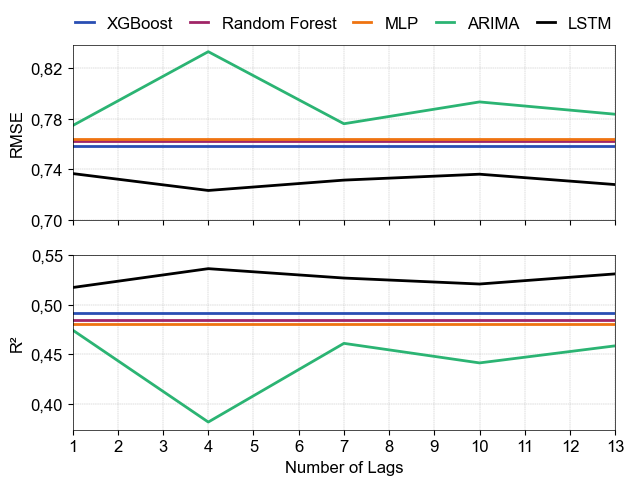

In [471]:
lags = range(1, 14, 3)

fig_all_models_lags, ax = plt.subplots(2, 1, figsize=(7, 5), sharex=True)

ax[0].plot(lags, rmse_list_xgb, label='XGBoost', c='#294EB3')
ax[0].plot(lags, rmse_list_rf, label='Random Forest', c='#A02567')
ax[0].plot(lags, rmse_list_mlp, label='MLP', c="#EF7310")
ax[0].plot(lags, rmse_list_arima, label='ARIMA', c='#2BB473')
ax[0].plot(lags, rmse_list_lstm, label='LSTM', c="k")

ax[1].plot(lags, r2_list_xgb, label='XGBoost', c='#294EB3')
ax[1].plot(lags, r2_list_rf, label='Random Forest', c='#A02567')
ax[1].plot(lags, r2_list_mlp, label='MLP', c='#EF7310')
ax[1].plot(lags, r2_list_arima, label='ARIMA', c='#2BB473')
ax[1].plot(lags, r2_list_lstm, label='LSTM', c='k')

ax[0].set_ylabel('RMSE')
ax[1].set_ylabel('R²')
ax[1].set_xlabel('Number of Lags')

ax[0].legend(ncol=5,
             loc='upper center',
             bbox_to_anchor=(0.5, 1.25),
             handlelength=1.1,
             columnspacing=1,
             frameon=False)

ax[1].set_xticks(range(1, 14))
ax[1].set_xlim(1, 13)

ax[0].set_yticks(np.arange(0.7, 0.83, 0.04))
ax[1].set_yticks(np.arange(0.4, 0.55, 0.05))

ax[0].grid(lw=0.3) 
ax[1].grid(lw=0.3) 

fig_all_models_lags.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\res-models-comparinson-lags.svg', dpi=140, format='svg', transparent=True)

plt.show()

In [472]:
metrics_df = pd.DataFrame({
    'n_lags': lags,
    'rmse_xgb': [round(x, 2) for x in rmse_list_xgb],
    'r2_xgb': [round(x, 2) for x in r2_list_xgb],
    'rmse_rf': [round(x, 2) for x in rmse_list_rf],
    'r2_rf': [round(x, 2) for x in r2_list_rf],
    'rmse_mlp': [round(x, 2) for x in rmse_list_mlp],
    'r2_mlp': [round(x, 2) for x in r2_list_mlp],
    'rmse_arima': [round(x, 2) for x in rmse_list_arima],
    'r2_arima': [round(x, 2) for x in r2_list_arima],
    'rmse_lstm': [round(x, 2) for x in rmse_list_lstm],
    'r2_lstm': [round(x, 2) for x in r2_list_lstm]
})

In [473]:
metrics_df

,n_lags,rmse_xgb,r2_xgb,rmse_rf,r2_rf,rmse_mlp,r2_mlp,rmse_arima,r2_arima,rmse_lstm,r2_lstm
0,1,0.76,0.49,0.76,0.48,0.76,0.48,0.77,0.47,0.74,0.52
1,4,0.76,0.49,0.76,0.48,0.76,0.48,0.83,0.38,0.72,0.54
2,7,0.76,0.49,0.76,0.48,0.76,0.48,0.78,0.46,0.73,0.53
3,10,0.76,0.49,0.76,0.48,0.76,0.48,0.79,0.44,0.74,0.52
4,13,0.76,0.49,0.76,0.48,0.76,0.48,0.78,0.46,0.73,0.53


In [474]:
metrics_df = metrics_df.set_index('n_lags')

In [475]:
metrics_df_r2 = metrics_df.filter(like='r2').copy()
metrics_df_rmse = metrics_df.filter(like='rmse').copy()

In [476]:
metrics_df_r2.T

n_lags,1,4,7,10,13
r2_xgb,0.49,0.49,0.49,0.49,0.49
r2_rf,0.48,0.48,0.48,0.48,0.48
r2_mlp,0.48,0.48,0.48,0.48,0.48
r2_arima,0.47,0.38,0.46,0.44,0.46
r2_lstm,0.52,0.54,0.53,0.52,0.53


In [477]:
metrics_df_rmse.T

n_lags,1,4,7,10,13
rmse_xgb,0.76,0.76,0.76,0.76,0.76
rmse_rf,0.76,0.76,0.76,0.76,0.76
rmse_mlp,0.76,0.76,0.76,0.76,0.76
rmse_arima,0.77,0.83,0.78,0.79,0.78
rmse_lstm,0.74,0.72,0.73,0.74,0.73


### 4.1 - Ploting Model Results

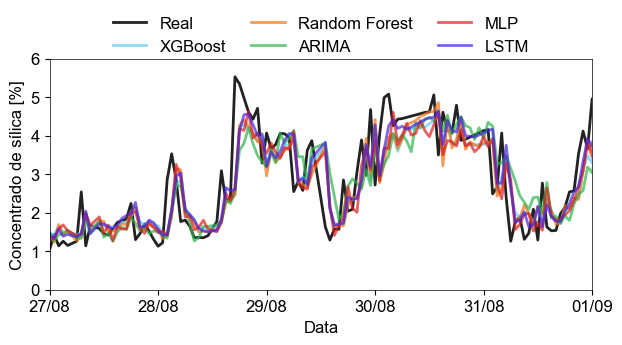

In [478]:
fig, ax = plt.subplots(figsize=(7, 3))

mpl.rc(('xtick', 'ytick'), labelsize=12)  # Axis tick label size
mpl.rc('font', family='Arial', size=12)  # Font family and font size

alp = 0.7

ax.plot(y_test.index, y_test, label='Real', c="#222222")
ax.plot(y_test_xgb.index, y_pred_xgb, label='XGBoost', c='#61CBF4', alpha=alp) 
ax.plot(y_test_rf.index, y_pred_rf, label='Random Forest', c="#EF7310", alpha=alp) 
ax.plot(y_test_arima.index, y_pred_arima, label='ARIMA', c="#2BB449", alpha=alp)
ax.plot(y_test_mlps.index, y_pred_mlps, label='MLP', c="#DA1C1C", alpha=alp)
ax.plot(y_test_lstm.index, y_pred_lstm, label='LSTM', c="#4623DF", alpha=alp)


ax.set_ylabel('Concentrado de sílica [%]')
ax.set_xlabel('Data')
ax.legend(loc='upper right')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

ax.set_xlim(pd.Timestamp('2017-08-27'), pd.Timestamp('2017-09-01'))
ax.set_yticks(np.arange(0, 7))

ax.legend(ncol=3,
             loc='upper center',
             bbox_to_anchor=(0.5, 1.25),
            #  handlelength=1.5,
             columnspacing=1.5,
             frameon=False)

# ax.set_xticks([pd.Timestamp('2017-08-27'), pd.Timestamp('2017-08-29'), pd.Timestamp('2017-08-31'), pd.Timestamp('2017-09-02'),
#                pd.Timestamp('2017-09-04'), pd.Timestamp('2017-09-06'), pd.Timestamp('2017-09-08'), pd.Timestamp('2017-09-10')])

fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\res-prediction.svg', dpi=140, format='svg', transparent=True)

plt.show()

In [479]:
# train_rmse = results['validation_0']['rmse']
# val_rmse   = results['validation_1']['rmse']

# fig_error, ax = plt.subplots(figsize=(6, 5))

# ax.plot(train_rmse, label='Train RMSE', c='#0B1741')
# ax.plot(val_rmse, label='Validation RMSE', c='#FF5733')

# ax.set_xlabel('Iteration')
# ax.set_ylabel('RMSE')
# ax.set_title('XGBoost Training vs Validation')
# ax.legend()

# ax.grid(True)
# ax.set_xlim(0, 800)

# # fig_error.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\fm_sc_errors_02.svg', dpi=140, format='svg', transparent=True)

# plt.show()

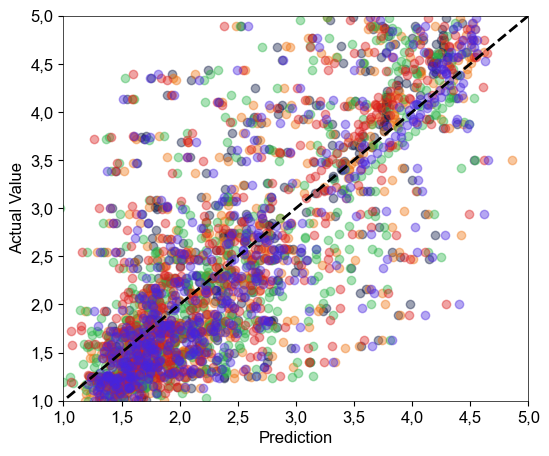

In [480]:
fig_scatter_error, ax = plt.subplots(figsize=(6, 5))

alp = 0.4

ax.scatter(y_pred_xgb, y_test_xgb, c='#0B1741', alpha=alp, label='XGBoost')
ax.scatter(y_pred_rf, y_test_rf, c='#EF7310', alpha=alp, label='Random Forest')
ax.scatter(y_pred_arima, y_test_arima, c='#2BB449', alpha=alp, label='ARIMA')
ax.scatter(y_pred_mlps, y_test_mlps, c='#DA1C1C', alpha=alp, label='MLP')
ax.scatter(y_pred_lstm, y_test_lstm, c='#4623DF', alpha=alp, label='LSTM')

ax.plot([0, 5], [0, 5], color='#000000', ls='--')

ax.set_xlabel('Prediction')
ax.set_ylabel('Actual Value')

ax.set_ylim(1, 5)
ax.set_xlim(1, 5)

plt.show()

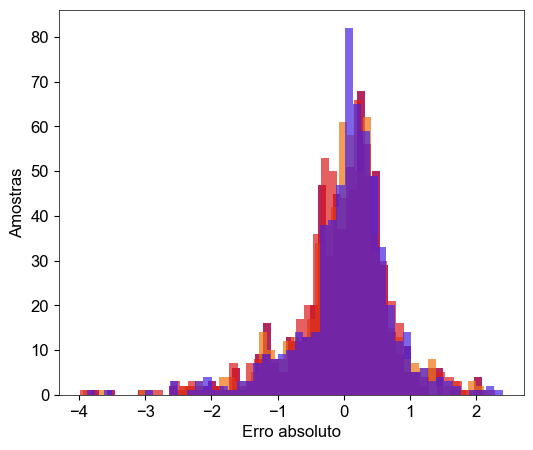

In [481]:
fig_hist_error, ax = plt.subplots(figsize=(6, 5))

y_pred_arima  = y_pred_arima.dropna()
y_test_arima  = y_test_arima.dropna()

ax.hist(y_pred_xgb - y_test_xgb, bins=50, color='#B2275F')
ax.hist(y_pred_rf - y_test_rf, bins=50, color='#EF7310', alpha=0.7)
# ax.hist(y_pred_arima - y_test_arima, bins=50, color='#2BB449', alpha=0.7)
ax.hist(y_pred_mlps - y_test_mlps, bins=50, color='#DA1C1C', alpha=0.7)
ax.hist(y_pred_lstm - y_test_lstm, bins=50, color='#4623DF', alpha=0.7)

ax.set_xlabel('Erro absoluto')
ax.set_ylabel('Amostras')

plt.show()

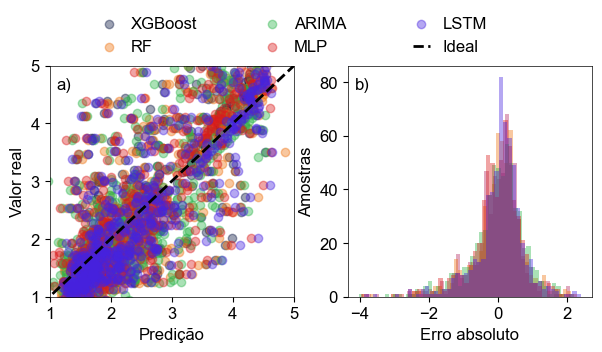

In [482]:
mpl.rc(('xtick', 'ytick'), labelsize=12)  # Axis tick label size
mpl.rc('font', family='Arial', size=12)  # Font family and font size

fig, ax = plt.subplots(1, 2, figsize=(7, 3))

fig.subplots_adjust(wspace=0.22)

alp = 0.4

ax[0].scatter(y_pred_xgb, y_test_xgb, c='#0B1741', alpha=alp, label='XGBoost')
ax[0].scatter(y_pred_rf, y_test_rf, c='#EF7310', alpha=alp, label='RF')
ax[0].scatter(y_pred_arima, y_test_arima, c='#2BB449', alpha=alp, label='ARIMA')
ax[0].scatter(y_pred_mlps, y_test_mlps, c='#DA1C1C', alpha=alp, label='MLP')
ax[0].scatter(y_pred_lstm, y_test_lstm, c='#4623DF', alpha=alp, label='LSTM')

ax[0].plot([0, 5], [0, 5], color='#000000', ls='--', label='Ideal')

ax[0].set_xlabel('Predição')
ax[0].set_ylabel('Valor real')

ax[0].set_ylim(1, 5)
ax[0].set_xlim(1, 5)



res_arima = np.asarray(y_pred_arima) - np.asarray(y_test_arima)

ax[1].hist(y_pred_xgb - y_test_xgb, bins=50, color='#B2275F', alpha=alp, label='XGBoost')
ax[1].hist(y_pred_rf - y_test_rf, bins=50, color='#EF7310', alpha=alp, label='RF')
ax[1].hist(res_arima, bins=50, color='#2BB449', alpha=alp, label='ARIMA')
ax[1].hist(y_pred_mlps - y_test_mlps, bins=50, color='#DA1C1C', alpha=alp, label='MLP')
ax[1].hist(y_pred_lstm - y_test_lstm, bins=50, color='#4623DF', alpha=alp, label='LSTM')

ax[1].set_xlabel('Erro absoluto')
ax[1].set_ylabel('Amostras')

# ax[0].set_title('a)', pad=60)
# ax[1].set_title('b)', pad=60)

ax[0].text(0.03, 0.95, 'a)', transform=ax[0].transAxes, fontsize=12, va='top')
ax[1].text(0.03, 0.95, 'b)', transform=ax[1].transAxes, fontsize=12, va='top')

ax[0].legend(
            ncol=3,
             loc='upper center',
             bbox_to_anchor=(1, 1.28),
             handlelength=1,
             columnspacing=4,
             frameon=False
             )

fig.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\res-models-comparinson-errors.svg', dpi=140, format='svg', transparent=True)

plt.show()


# 05 - Predicting the Future

In [494]:
future = 24 * 2

# índice temporal (use o do y_test correspondente)
idx_future = y_test_xgb.iloc[-future:].index

# colunas (use as do seu DataFrame tabular)
cols_tabular = X_test_xgb.columns

# garante que MLP está em DataFrame
if not hasattr(X_test_mlps, "iloc"):
    X_test_mlps = pd.DataFrame(X_test_mlps, columns=cols_tabular, index=y_test_mlps.index)

X_test_future_xgb = X_test_xgb.iloc[-future:].copy()
X_test_future_rf  = X_test_rf.iloc[-future:].copy()
X_test_future_mlp = X_test_mlps.iloc[-future:].copy()


In [495]:
import numpy as np

def recursive_forecast_tabular(model, X_seed: pd.DataFrame, horizon: int, lag_cols=None):
    Xf = X_seed.copy(deep=True)

    if lag_cols is None:
        lag_cols = [c for c in Xf.columns if str(c).startswith("lag-")]
        lag_cols = sorted(lag_cols, key=lambda x: int(str(x).split("-")[1]))  # lag-1, lag-2, ...

    preds = np.zeros(horizon, dtype=float)

    for i in range(horizon):
        yhat = model.predict(Xf.iloc[[i]])
        yhat = float(np.ravel(yhat)[0])
        preds[i] = yhat

        if i < horizon - 1:
            # shift lags na próxima linha
            for j in range(len(lag_cols) - 1, 0, -1):
                Xf.loc[Xf.index[i+1], lag_cols[j]] = Xf.loc[Xf.index[i], lag_cols[j-1]]
            Xf.loc[Xf.index[i+1], lag_cols[0]] = yhat

    return preds


In [496]:
pred_future_xgb = recursive_forecast_tabular(model_xgb, X_test_future_xgb, future)
pred_future_rf  = recursive_forecast_tabular(model_rf,  X_test_future_rf,  future)
pred_future_mlp = recursive_forecast_tabular(model_mlp, X_test_future_mlp, future)


c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but MLPRegressor was fitted without feature names
  warnings.warn(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but MLPRegressor was fitted without feature names
  warnings.warn(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but MLPRegressor was fitted without feature names
  warnings.warn(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but MLPRegressor was fitted without feature names
  warnings.warn(
c:\Users\paulo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but MLPRegressor was fitted without feature names
  warnings.warn(
c:\Users\paulo\AppData\Local\P

In [499]:
type(model_arima)



statsmodels.tsa.statespace.sarimax.SARIMAX

In [ ]:
pred_future_arima = np.asarray(model_arima.predict(n_periods=future), dtype=float)


In [ ]:
pred_future_lstm = model_lstm.predict(X_test_lstm[-future:])
pred_future_lstm = np.ravel(pred_future_lstm).astype(float)


In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

y_true_future = y_test_xgb.iloc[-future:].copy()
idx = y_true_future.index

fig_fut, ax = plt.subplots(figsize=(10, 5))

ax.plot(idx, y_true_future.values, c="#0B1741", label="Target", linewidth=2)

ax.plot(idx, pred_future_xgb,  c="#FF5733", label="XGBoost", marker="o", alpha=0.8)
ax.plot(idx, pred_future_rf,   c="#EF7310", label="RF",      marker="o", alpha=0.8)
ax.plot(idx, pred_future_arima,c="#2BB449", label="ARIMA",   marker="o", alpha=0.8)
ax.plot(idx, pred_future_mlp,  c="#DA1C1C", label="MLP",     marker="o", alpha=0.8)
ax.plot(idx, pred_future_lstm, c="#4623DF", label="LSTM",    marker="o", alpha=0.8)

ax.set_ylabel("Silica Concentrate [%]")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.legend()
plt.show()


In [ ]:
# import matplotlib.dates as mdates
# import matplotlib.pyplot as plt

# idx = y_true_future.index  # índice de datas do seu teste

# fig_fut, ax = plt.subplots(figsize=(10, 5))

# ax.plot(idx, y_true_future.values, label="Target", color="#0B1741", linewidth=2)

# ax.plot(idx, pred_xgb, label="XGBoost", color="#FF5733", marker="o", alpha=0.8)
# ax.plot(idx, pred_rf,  label="RF",      color="#EF7310", marker="o", alpha=0.8)
# ax.plot(idx, pred_mlp, label="MLP",     color="#DA1C1C", marker="o", alpha=0.8)

# ax.set_ylabel("Silica Concentrate [%]")
# ax.set_xlabel("Date")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
# ax.legend()
# plt.show()


In [ ]:
future = 24 * 2 # in hours (1 day)

X_test_future_xgb = X_test_xgb.iloc[-future:]
X_test_future_rf = X_test_rf.iloc[-future:]
X_test_future_arima = X_test_arima.iloc[-future:]
X_test_future_mlp = X_test_mlps[-future:]
X_test_future_lstm = X_test_lstm[-future:]

In [ ]:
for i in range(future):
    if i == 0:
        y_pred_future_xgb = model_xgb.predict(X_test_future_xgb.iloc[[i]])
        y_pred_future_rf = model_rf.predict(X_test_future_rf.iloc[[i]])
        y_pred_future_arima = model_arima.predict(X_test_future_arima.iloc[[i]])
        y_pred_future_mlp = model_mlp.predict(X_test_future_mlp.iloc[[i]])
        y_pred_future_lstm = model_lstm.predict(X_test_future_lstm.iloc[[i]])
    else:
        X_test_future_xgb.iloc[[i], 0] = y_pred_future_xgb
        X_test_future_rf.iloc[[i], 0] = y_pred_future_rf
        X_test_future_arima.iloc[[i], 0] = y_pred_future_arima
        X_test_future_mlp.iloc[[i], 0] = y_pred_future_mlp
        X_test_future_lstm.iloc[[i], 0] = y_pred_future_lstm
        
        print(y_pred_future_xgb, y_pred_future_rf, y_pred_future_arima, y_pred_future_mlp, y_pred_future_lstm)
        for j in range(1, X_test_future_xgb.shape[1] - 1):
            X_test_future_xgb.iloc[[i], j] = X_test_future_xgb.iloc[[i], j + 1]
            X_test_future_rf.iloc[[i], j] = X_test_future_rf.iloc[[i], j + 1]
            X_test_future_arima.iloc[[i], j] = X_test_future_arima.iloc[[i], j + 1]
            X_test_future_mlp.iloc[[i], j] = X_test_future_mlp.iloc[[i], j + 1]
            X_test_future_lstm.iloc[[i], j] = X_test_future_lstm.iloc[[i], j + 1]

        
        y_pred_future_xgb = model_xgb.predict(X_test_future_xgb.iloc[[i]])
        y_pred_future_rf = model_rf.predict(X_test_future_rf.iloc[[i]])
        y_pred_future_arima = model_arima.predict(X_test_future_arima.iloc[[i]])
        y_pred_future_mlp = model_mlp.predict(X_test_future_mlp.iloc[[i]])
        y_pred_future_lstm = model_lstm.predict(X_test_future_lstm.iloc[[i]])

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [ ]:
y_test_future_xgb = y_test_xgb.iloc[-future:].copy()
y_test_future_rf = y_test_rf.iloc[-future:].copy()
y_test_future_arima = y_test_arima.iloc[-future:].copy()
y_test_future_mlp = y_test_mlps.iloc[-future:].copy()
y_test_future_lstm = y_test_lstm.iloc[-future:].copy()

In [ ]:
X_test_future.head()

,lag-1,lag-2,lag-3,lag-4,lag-5,lag-6,lag-7,lag-8,lag-9,lag-10,lag-11,lag-12,lag-13,lag-14
date,,,,,,,,,,,,,,
2017-09-07 22:00:00,1.440000,1.72,2.05,1.90,2.15,1.98,2.46,2.66,2.47,2.23,1.85,1.57,1.54,1.49
2017-09-08 00:00:00,1.751586,1.72,2.05,1.90,2.15,1.98,2.46,2.66,2.47,2.23,1.85,1.57,1.54,1.54
2017-09-08 01:00:00,1.836535,1.44,1.72,2.05,1.90,2.15,1.98,2.46,2.66,2.47,2.23,1.85,1.57,1.57
2017-09-08 02:00:00,1.910831,1.36,1.44,1.72,2.05,1.90,2.15,1.98,2.46,2.66,2.47,2.23,1.85,1.85
2017-09-08 03:00:00,1.963948,1.26,1.36,1.44,1.72,2.05,1.90,2.15,1.98,2.46,2.66,2.47,2.23,2.23


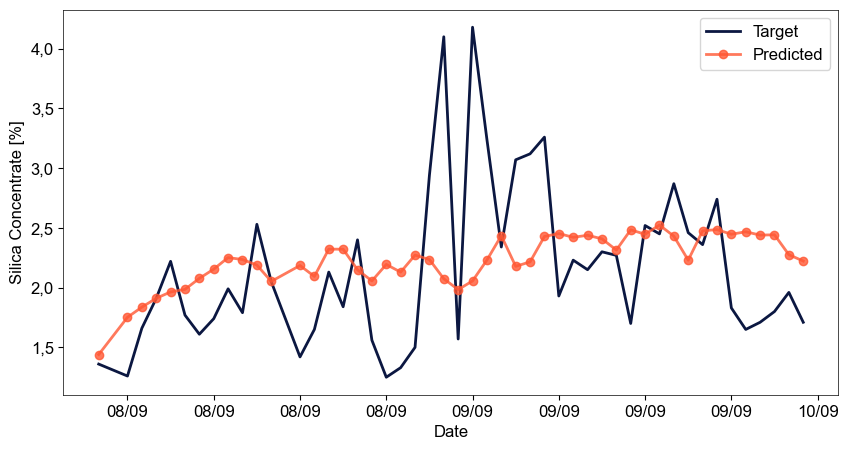

In [ ]:
fig_fut, ax = plt.subplots(figsize=(10, 5))

ax.plot(y_test_future, c='#0B1741', label='Target')
ax.plot(X_test_future.index, X_test_future['lag-1'], c='#FF5733', label='Predicted', marker='o', alpha=0.8)

ax.set_ylabel('Silica Concentrate [%]')
ax.set_xlabel('Date')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

ax.legend()

# fig_fut.savefig(r'G:\Meu Drive\03 - Facens\03 - Data Science\02-TCC-POS\05-Figures\future-predict.svg', dpi=140, format='svg', transparent=True)

plt.show()

The chart demonstrates that the model is capable of predicting up to a 3-hour horizon with relative low errors.

---